# Introduction

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview

In [3]:
# CSV faylının oxunması
df = pd.read_csv("who_suicide_statistics.csv")

# Dataset-in ölçüsü və strukturu
print(df.shape)
print(df.columns)
df.info()

# İlk 5 sətirə baxış
df.head()


(43776, 6)
Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43776 entries, 0 to 43775
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      43776 non-null  object 
 1   year         43776 non-null  int64  
 2   sex          43776 non-null  object 
 3   age          43776 non-null  object 
 4   suicides_no  41520 non-null  float64
 5   population   38316 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 2.0+ MB


,country,year,sex,age,suicides_no,population
0,Albania,1985,female,15-24 years,NaN,277900.0
1,Albania,1985,female,25-34 years,NaN,246800.0
2,Albania,1985,female,35-54 years,NaN,267500.0
3,Albania,1985,female,5-14 years,NaN,298300.0
4,Albania,1985,female,55-74 years,NaN,138700.0


# Research Questions

# Data Cleaning and Preparation

In [4]:
# Boş dəyərlərin doldurulması
df.fillna(0, inplace=True)

# Təkrarlanan sətirlərin silinməsi
df.drop_duplicates(inplace=True)

# Data tiplərinin düzəldilməsi
df['year'] = df['year'].astype(int)
df['population'] = df['population'].astype(int)

# Təmizlənmiş data yoxlanışı
df.head()

,country,year,sex,age,suicides_no,population
0,Albania,1985,female,15-24 years,0.0,277900
1,Albania,1985,female,25-34 years,0.0,246800
2,Albania,1985,female,35-54 years,0.0,267500
3,Albania,1985,female,5-14 years,0.0,298300
4,Albania,1985,female,55-74 years,0.0,138700


# Exploratory Data Analysis (EDA)

               year   suicides_no    population
count  43776.000000  43776.000000  4.377600e+04
mean    1998.502467    183.352865  1.456536e+06
std       10.338711    780.857898  3.456217e+06
min     1979.000000      0.000000  0.000000e+00
25%     1990.000000      0.000000  2.520000e+04
50%     1999.000000     11.000000  2.979955e+05
75%     2007.000000     83.000000  1.067009e+06
max     2016.000000  22338.000000  4.380521e+07


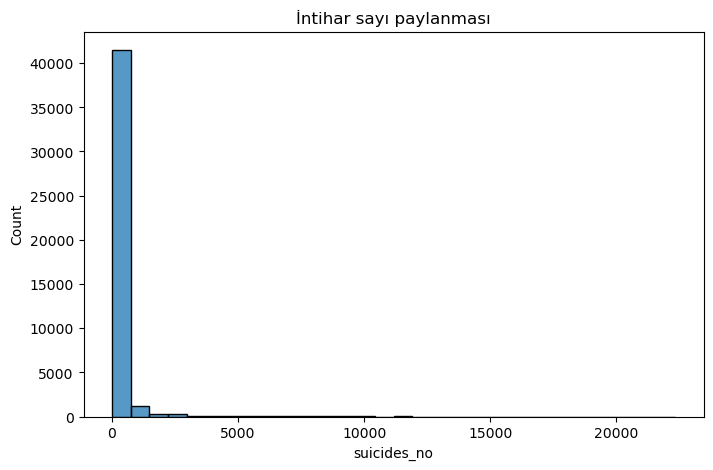

In [5]:
# Statistik göstəricilər
print(df.describe())

# İntihar sayı paylanması
plt.figure(figsize=(8,5))
sns.histplot(df['suicides_no'], bins=30)
plt.title("İntihar sayı paylanması")
plt.show()


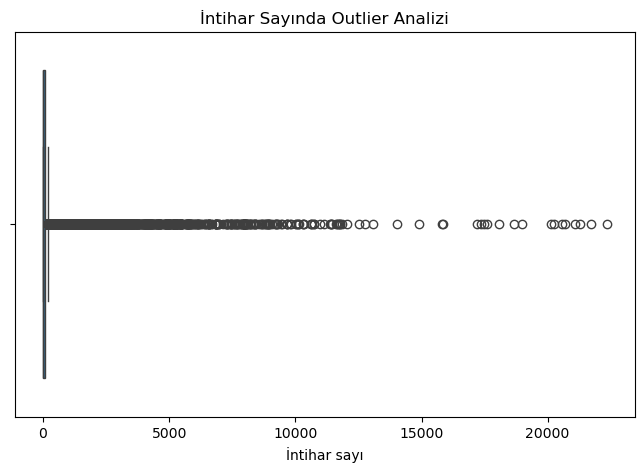

In [6]:
# İntihar sayında outlier analizi
plt.figure(figsize=(8,5))
sns.boxplot(x=df['suicides_no'])
plt.title("İntihar Sayında Outlier Analizi")
plt.xlabel("İntihar sayı")
plt.show()

# Temporal Analysis (Zaman üzrə analiz)

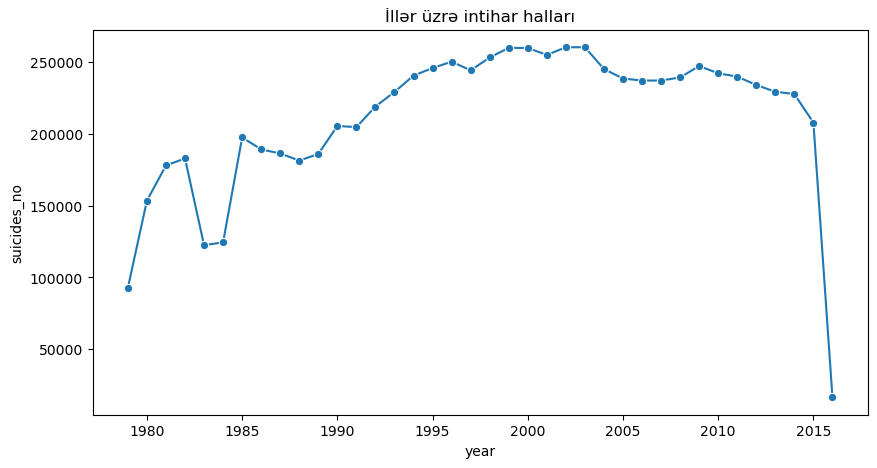

In [24]:
# İllər üzrə intihar halları
yearly = df.groupby('year')['suicides_no'].sum().reset_in dex()

plt.figure(figsize=(10,5))
sns.lineplot(data=yearly, x='year', y='suicides_no', marker='o')
plt.title("İllər üzrə intihar halları")
plt.show()

# Demographic Analysis(Cins və yaş)

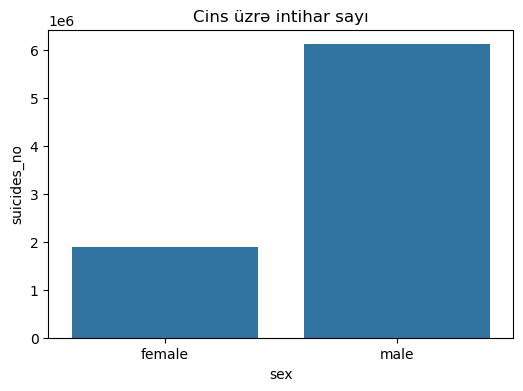

In [27]:
# Cins üzrə
gender_group = df.groupby('sex')['suicides_no'].sum().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=gender_group, x='sex', y='suicides_no')
plt.title("Cins üzrə intihar sayı")
plt.show()

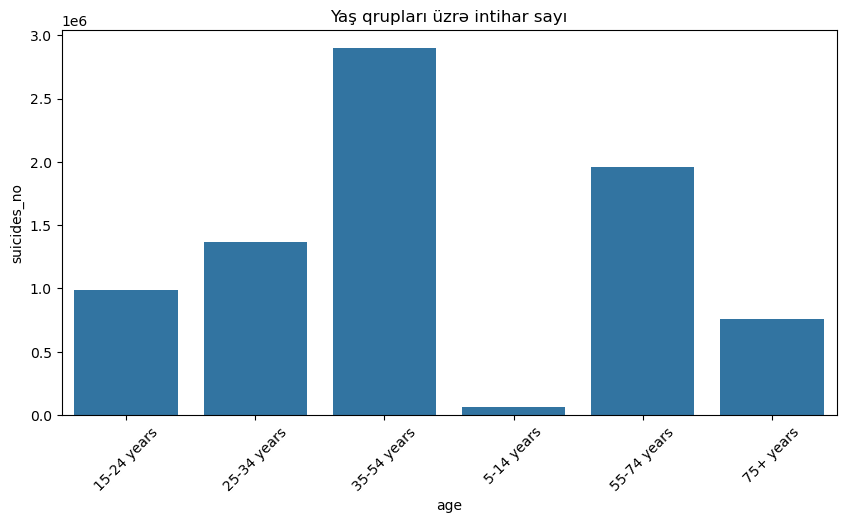

In [28]:
# Yaş qrupları üzrə
age_group = df.groupby('age')['suicides_no'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=age_group, x='age', y='suicides_no')
plt.xticks(rotation=45)
plt.title("Yaş qrupları üzrə intihar sayı")
plt.show()

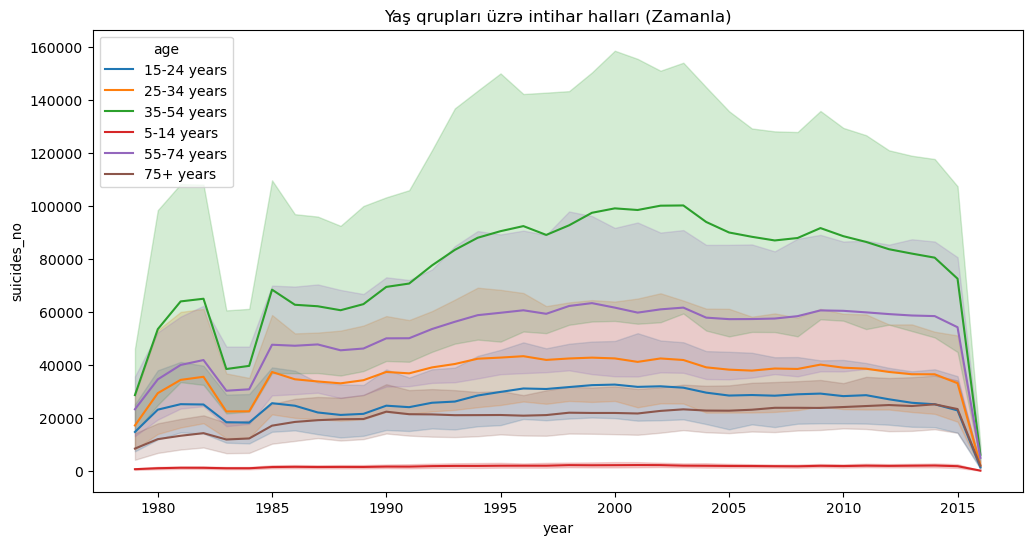

In [34]:
# Yaş qrupları üzrə zamanla trend
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='year', y='suicides_no', hue='age', estimator='sum')
plt.title("Yaş qrupları üzrə intihar halları (Zamanla)")
plt.show()

# Country-Level Comparison(Ölkələr üzrə)

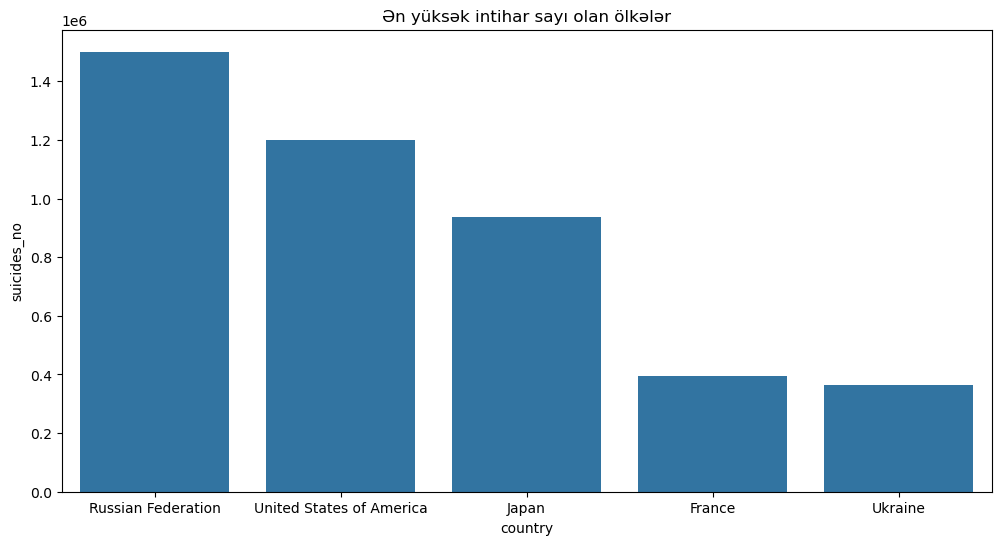

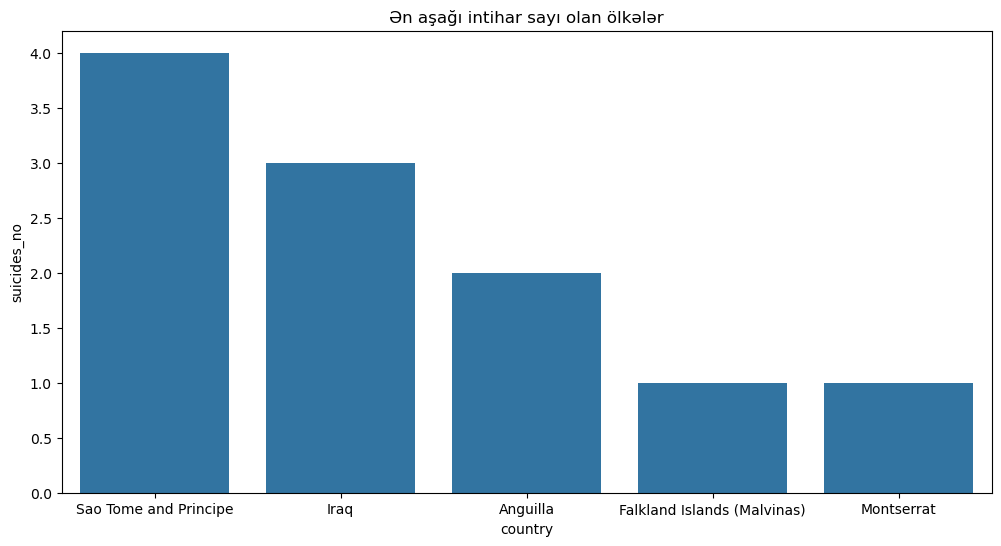

In [30]:
country_total = df.groupby('country')['suicides_no'].sum().sort_values(ascending=False).reset_index()

top_countries = country_total.head(5)
bottom_countries = country_total.tail(5)

# Ən yüksək göstəricili ölkələr
plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, x='country', y='suicides_no')
plt.title("Ən yüksək intihar sayı olan ölkələr")
plt.show()

# Ən aşağı göstəricili ölkələr
plt.figure(figsize=(12,6))
sns.barplot(data=bottom_countries, x='country', y='suicides_no')
plt.title("Ən aşağı intihar sayı olan ölkələr")
plt.show()


# Population vs Suicides (Əhali ilə müqayisə)

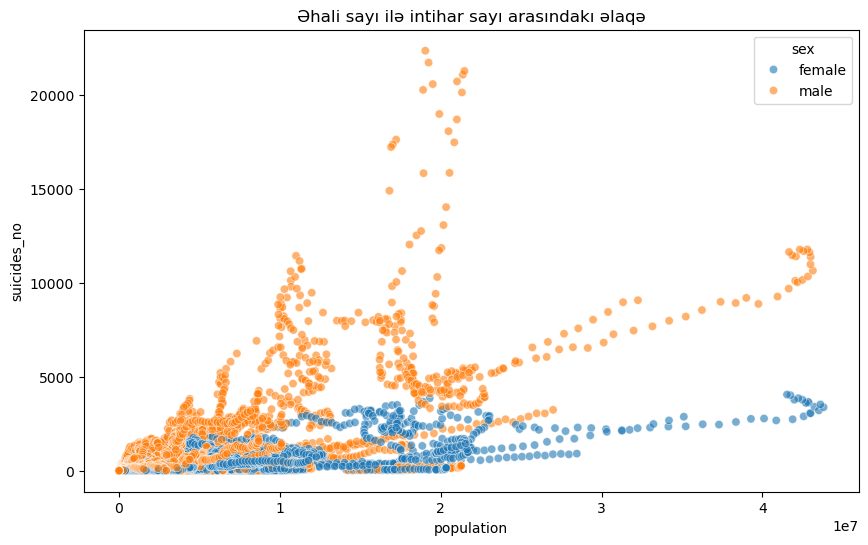

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='population', y='suicides_no', hue='sex', alpha=0.6)
plt.title("Əhali sayı ilə intihar sayı arasındakı əlaqə")
plt.show()

# Most Risky Demographic Groups (Ən riskli qruplar)

In [33]:
risk_group = df.groupby(['sex','age'])['suicides_no'].sum().sort_values(ascending=False).reset_index()
risk_group.head(5)

,sex,age,suicides_no
0,male,35-54 years,2286377.0
1,male,55-74 years,1429445.0
2,male,25-34 years,1109311.0
3,male,15-24 years,762550.0
4,female,35-54 years,609011.0


# Conclusion